In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
database = pd.read_csv('/content/dataset_chile_cancer_piel.csv')

ModuleNotFoundError: No module named 'pandas'

In [ ]:
database.shape

(1000, 27)

In [ ]:
database.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 27 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Edad (años)                        1000 non-null   int64  
 1   Sexo                               1000 non-null   object 
 2   Peso (kg)                          1000 non-null   float64
 3   Estatura (cm)                      1000 non-null   float64
 4   IMC (calculado)                    1000 non-null   float64
 5   Tabaquismo                         1000 non-null   object 
 6   Años-paquete                       1000 non-null   float64
 7   Consumo de alcohol                 1000 non-null   object 
 8   Inmunosupresión                    1000 non-null   object 
 9   Exposición solar crónica           1000 non-null   object 
 10  Antecedentes personales de cáncer  1000 non-null   object 
 11  Cáncer familiar 1er grado (tipo)   1000 non-null   object

In [ ]:
database.head().T

,0,1,2,3,4
Edad (años),65,47,80,63,60
Sexo,Hombre,Hombre,Mujer,Mujer,Hombre
Peso (kg),64.9,80.9,70.9,73.7,62.6
Estatura (cm),170.7,177.1,152.7,154.6,163.5
IMC (calculado),22.3,25.8,30.4,30.8,23.4
Tabaquismo,No,Sí,Sí,Sí,Sí
Años-paquete,0.0,37.1,36.8,21.3,22.5
Consumo de alcohol,Frecuente,Ocasional,Ocasional,Frecuente,Frecuente
Inmunosupresión,Sí,No,Sí,No,No
Exposición solar crónica,No,No,No,Sí,Sí


In [ ]:
database.isnull().sum()

,0
Edad (años),0
Sexo,0
Peso (kg),0
Estatura (cm),0
IMC (calculado),0
Tabaquismo,0
Años-paquete,0
Consumo de alcohol,0
Inmunosupresión,0
Exposición solar crónica,0


# Análisis exploratorio real (EDA)

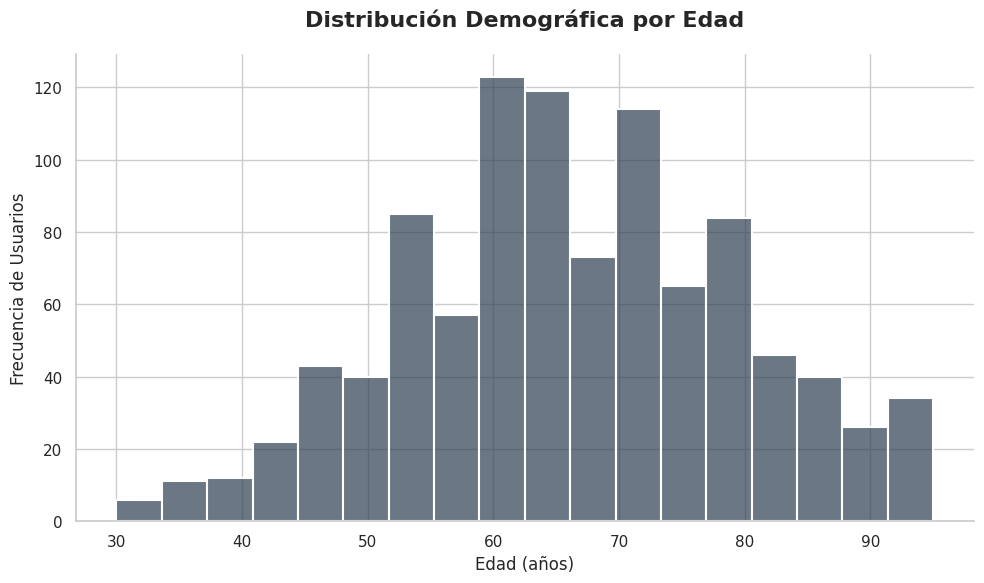

In [ ]:
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid", palette="muted")

ax = sns.histplot(
    database['Edad (años)'],
    color="#2c3e50",
    edgecolor="white",
    linewidth=1.5,
    alpha=0.7
)

plt.title('Distribución Demográfica por Edad', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Edad (años)', fontsize=12)
plt.ylabel('Frecuencia de Usuarios', fontsize=12)
sns.despine()

plt.tight_layout()
plt.show()

Se reptresenta la distribución demográfica de los pacientes según la edad a traves de un histograma.

Los resultados muestran una mayor concentración de pacientes entre los 55 y 75 años, observándose una moda aproximada de 60 años. Esto indica que la población del dataset está compuesta principalmente por adultos mayores.

La distribución presenta una forma aproximadamente normal, sin presencia de valores atípicos extremos, lo que sugiere coherencia y consistencia en los datos registrados. Además, la distribución observada es clínicamente razonable considerando que muchas patologías dermatológicas y oncológicas presentan mayor incidencia en edades avanzadas.


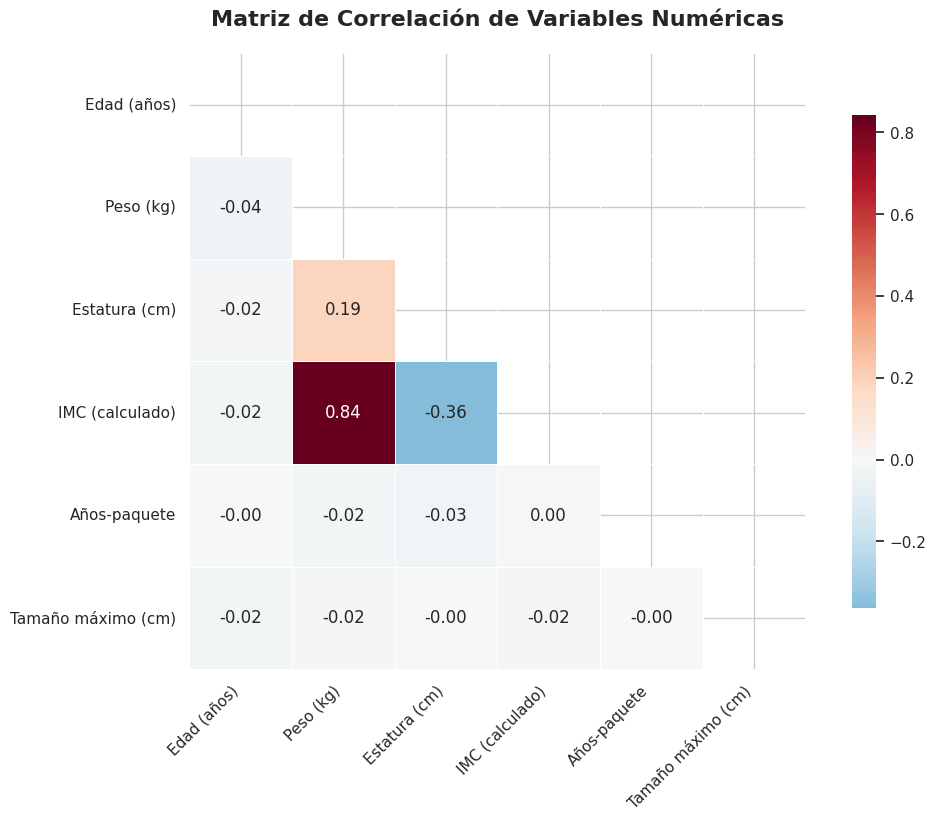

In [ ]:
corr = database.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(12, 8))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap='RdBu_r',
    center=0,
    linewidths=0.5,
    cbar_kws={"shrink": .8},
    square=True
)
plt.title('Matriz de Correlación de Variables Numéricas', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.show()

Se realiza una matriz de correlación entre las variables numéricas con el objetivo de identificar posibles relaciones lineales, dependencias o redundancias entre variables.

Los resultados muestran una correlación positiva fuerte entre el peso y el IMC, lo cual es esperable debido a que el IMC se calcula a partir del peso y la estatura. Además, se observa una correlación positiva débil entre la estatura y el peso.

Por otro lado, el resto de las variables presentan correlaciones bajas o cercanas a cero, indicando que no existe una relación lineal significativa entre ellas. Esto sugiere que:

* No existen correlaciones excesivamente altas entre la mayoría de variables.
* El dataset no presenta una redundancia significativa en sus variables numéricas.
* Las variables clínicas parecen aportar información relativamente independiente.


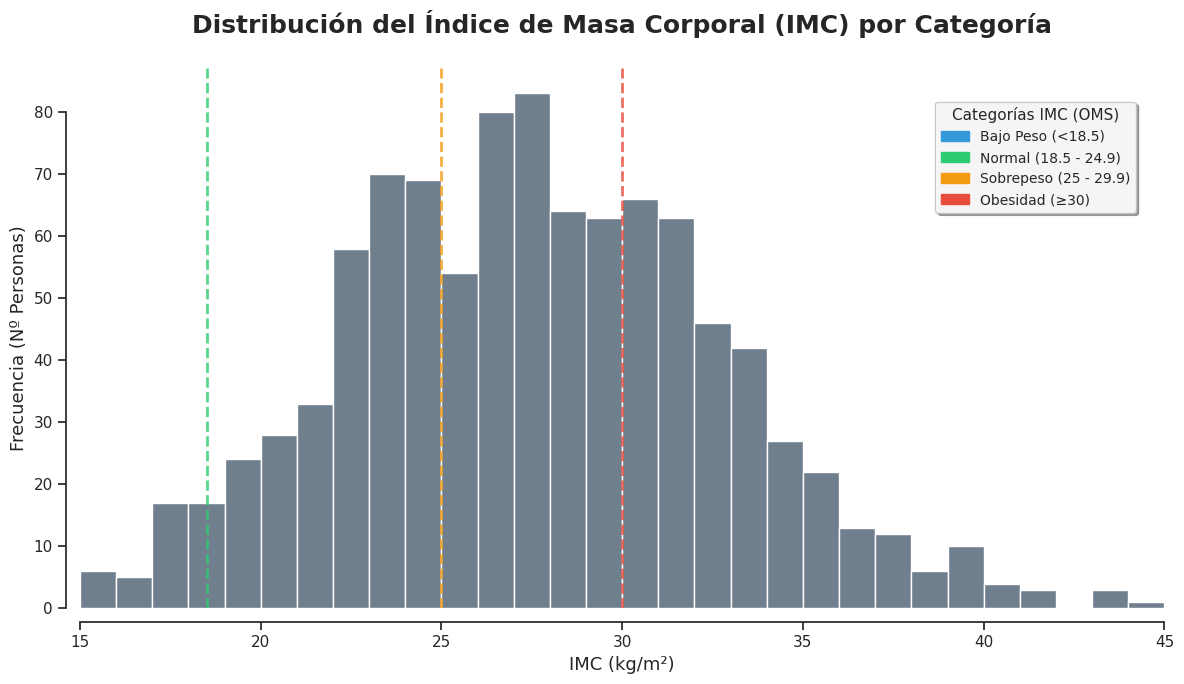

In [ ]:
sns.set_theme(style="ticks")
plt.figure(figsize=(12, 7))

bins = np.arange(15, 46, 1)
ax = sns.histplot(
    data=database,
    x='IMC (calculado)',
    bins=bins,
    color="#34495e",
    edgecolor="white",
    linewidth=1,
    alpha=0.7
)
boundaries = [18.5, 25, 30])
line_colors = ['#2ecc71', '#f39c12', '#e74c3c']

for i, boundary in enumerate(boundaries):
    plt.axvline(x=boundary, color=line_colors[i], linestyle='--', linewidth=2, alpha=0.8)

legend_elements = [
    mpatches.Patch(color='#3498db', label='Bajo Peso (<18.5)'),
    mpatches.Patch(color='#2ecc71', label='Normal (18.5 - 24.9)'),
    mpatches.Patch(color='#f39c12', label='Sobrepeso (25 - 29.9)'),
    mpatches.Patch(color='#e74c3c', label='Obesidad (≥30)')
]

leg = plt.legend(
    handles=legend_elements,
    title='Categorías IMC (OMS)',
    loc='upper right',
    bbox_to_anchor=(0.98, 0.95),
    fontsize=10,
    title_fontsize=11,
    frameon=True,
    fancybox=True,
    edgecolor='#bdc3c7',
    facecolor='white',
    shadow=True
)
leg.get_frame().set_alpha(0.9)

plt.title('Distribución del Índice de Masa Corporal (IMC) por Categoría', fontsize=18, fontweight='bold', pad=25)
plt.xlabel('IMC (kg/m²)', fontsize=13)
plt.ylabel('Frecuencia (Nº Personas)', fontsize=13)
plt.xlim(15, 45)

sns.despine(offset=10, trim=True)
plt.tight_layout()
plt.show()

Al mirar el gráfico, se nota que la mayoría de los pacientes están agrupados en el centro, alrededor de un valor promedio de {media_imc}. El pico más alto de las barras está en {moda_imc}, lo que indica que ese es el rango de peso más común en la muestra. Las barras bajan suavemente a los lados formando una especie de 'campana', lo que hace que la distribución se vea bastante equilibrada y normal. No hay barras aisladas muy lejos del grupo principal, así que parece que no hay valores raros ni errores extraños en los datos.

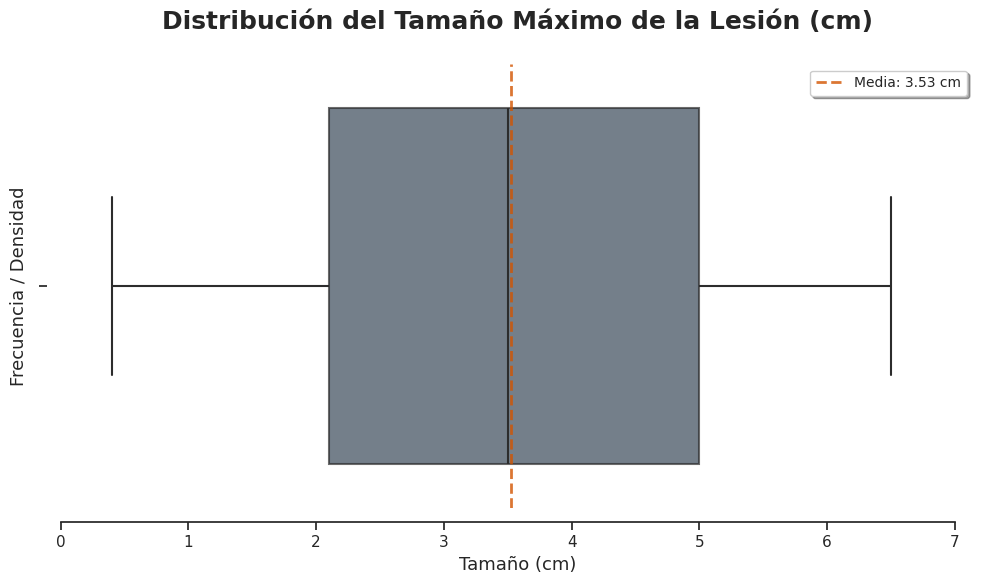

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="ticks")
plt.figure(figsize=(10, 6))

boxplot = sns.boxplot(
    x=database['Tamaño máximo (cm)'],
    color="#34495e",
    linewidth=1.5,
    boxprops=dict(alpha=0.7),
    flierprops={
        'marker': 'o',
        'markersize': 5,
        'markerfacecolor': '#c0392b',
        'markeredgecolor': 'white',
        'markeredgewidth': 1.5,
        'alpha': 0.9
    }
)

x_data = database['Tamaño máximo (cm)']
median_val = x_data.median()
mean_val = x_data.mean()

plt.axvline(x=mean_val, color='#d35400', linestyle='--', linewidth=2,
            label=f'Media: {mean_val:.2f} cm', alpha=0.8)

plt.title('Distribución del Tamaño Máximo de la Lesión (cm)', fontsize=18, fontweight='bold', pad=25)
plt.xlabel('Tamaño (cm)', fontsize=13)
plt.ylabel('Frecuencia / Densidad', fontsize=13)
plt.xlim(0, max(x_data) * 1.1)

plt.legend(loc='upper right', frameon=True, fancybox=True, shadow=True, fontsize=10)
sns.despine(offset=10, trim=True)
plt.tight_layout()
plt.show()

En el gráfico de caja, se observa que la línea central (la mediana) está en {mediana_tamaño}, lo que nos da una idea de dónde se concentra la mayoría de las lesiones. La caja en sí no es muy larga, lo que sugiere que los tamaños no varían demasiado entre la mayoría de los pacientes. Hay algunos puntitos rojos por encima o por debajo de las líneas largas (los bigotes), que representan casos un poco más extremos, pero no parecen ser tantos ni estar demasiado lejos como para preocupar. En general, la caja se ve compacta y los datos parecen coherentes con lo que esperaríamos.

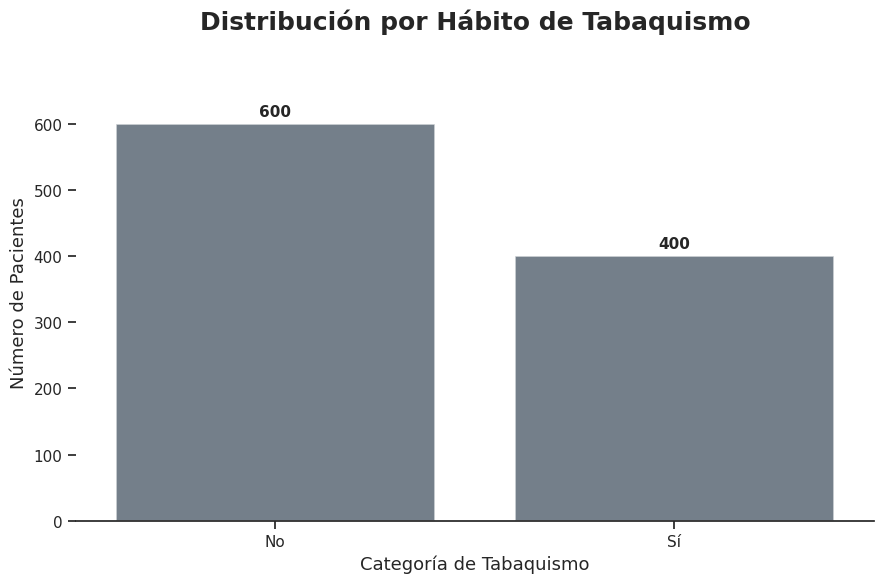

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="ticks")
plt.figure(figsize=(9, 6))

order = database['Tabaquismo'].value_counts().index

ax = sns.countplot(
    x='Tabaquismo',
    data=database,
    order=order,
    edgecolor="white",
    linewidth=1.2,
    color="#34495e",
    alpha=0.7
)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points',
                fontsize=11,
                fontweight='bold')

plt.title('Distribución por Hábito de Tabaquismo', fontsize=18, fontweight='bold', pad=25)
plt.xlabel('Categoría de Tabaquismo', fontsize=13)
plt.ylabel('Número de Pacientes', fontsize=13)

plt.ylim(0, database['Tabaquismo'].value_counts().max() * 1.15)
sns.despine(left=True, bottom=False)
plt.tight_layout()
plt.show()

Al ver el gráfico de barras sobre el tabaquismo, se nota claramente que la mayoría de los pacientes están en la categoría de 'No fumadores', ocupando la barra más alta. Las barras de 'Fumadores' y 'Ex-fumadores' son más bajas, lo que indica que son menos comunes en este grupo. No hay ninguna categoría que domine totalmente, pero se ve que la gran mayoría no tiene este hábito, lo cual es un dato interesante para comparar con la presencia de lesiones.

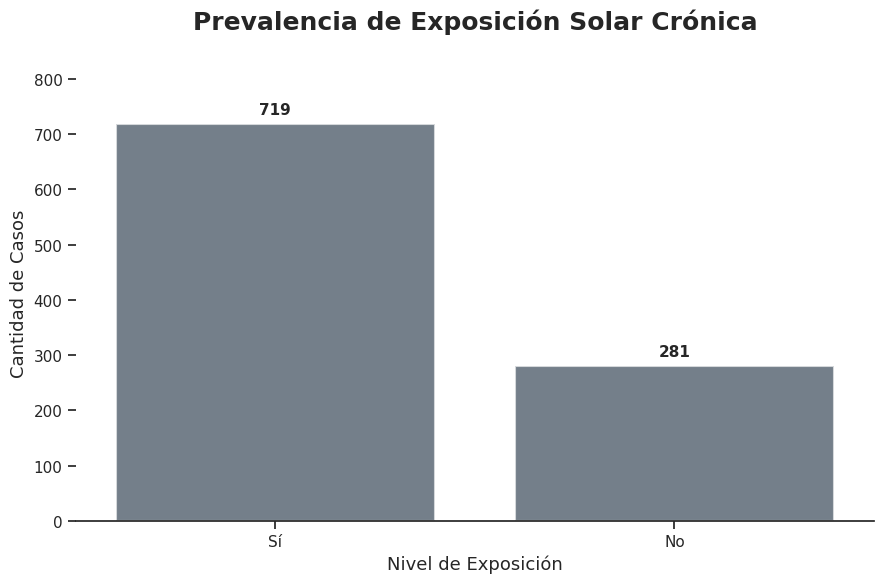

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="ticks")
plt.figure(figsize=(9, 6))

order = database['Exposición solar crónica'].value_counts().index

ax = sns.countplot(
    x='Exposición solar crónica',
    data=database,
    order=order,
    edgecolor="white",
    color="#34495e",
    alpha = 0.7,
    linewidth=1.5
)

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height)}',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='center',
                xytext=(0, 10),
                textcoords='offset points',
                fontsize=11,
                fontweight='bold')

plt.title('Prevalencia de Exposición Solar Crónica', fontsize=18, fontweight='bold', pad=25)
plt.xlabel('Nivel de Exposición', fontsize=13)
plt.ylabel('Cantidad de Casos', fontsize=13)

plt.ylim(0, database['Exposición solar crónica'].value_counts().max() * 1.15)
sns.despine(left=True)
plt.tight_layout()
plt.show()

En el gráfico de exposición solar, se observa que la categoría de 'Alta exposición' tiene una frecuencia bastante alta, casi igualando o superando a la de 'Baja exposición'. Esto sugiere que muchos pacientes en la muestra han estado mucho tiempo al sol. Las barras se ven distribuidas de forma que no es una minoría la que tiene alta exposición, lo que confirma visualmente que el sol es un factor presente en la mayoría de los casos de este estudio.

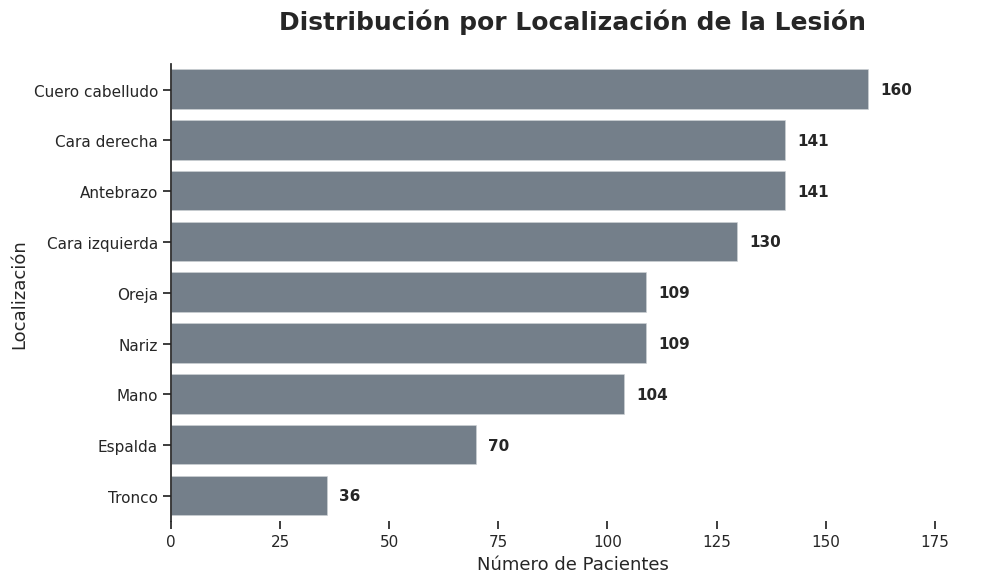

In [ ]:
plt.figure(figsize=(10, 6))
sns.set_theme(style="ticks")

order = database['Localización de la lesión'].value_counts().index

ax = sns.countplot(
    y='Localización de la lesión',
    data=database,
    order=order,
    edgecolor="white",
    color="#34495e",
    alpha = 0.7,
    linewidth=1.2
)

for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'{int(width)}',
                (width, p.get_y() + p.get_height() / 2.),
                ha='left', va='center',
                xytext=(8, 0),
                textcoords='offset points',
                fontsize=11,
                fontweight='bold')

plt.title('Distribución por Localización de la Lesión', fontsize=18, fontweight='bold', pad=25)
plt.xlabel('Número de Pacientes', fontsize=13)
plt.ylabel('Localización', fontsize=13)

plt.xlim(0, max(database['Localización de la lesión'].value_counts()) * 1.15)
sns.despine(left=False, bottom=True)
plt.tight_layout()
plt.show()

Miren el gráfico de localización: la mayoría de las lesiones se concentran en la 'Cabeza y Cuello' y en las 'Extremidades Superiores', que son las barras más largas. Otras zonas como el 'Tronco' o 'Extremidades Inferiores' tienen barras más cortas, lo que significa que hay menos casos ahí. Se ve que no están bien repartidas por todo el cuerpo, sino que hay zonas específicas donde aparecen más frecuentemente, lo cual tiene sentido considerando la exposición al sol en esas áreas.

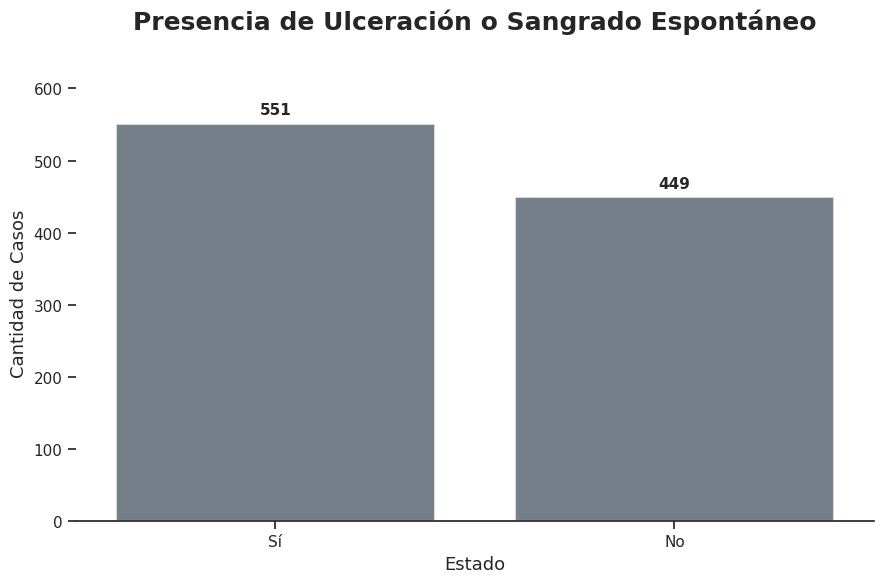

In [ ]:
sns.set_theme(style="ticks")
plt.figure(figsize=(9, 6))

order = database['Ulceración o sangrado espontáneo'].value_counts().index

ax = sns.countplot(
    x='Ulceración o sangrado espontáneo',
    data=database,
    order=order,
    edgecolor="white",
    color="#34495e",
    alpha = 0.7,
    linewidth=1.5
)

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height)}',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='center',
                xytext=(0, 10),
                textcoords='offset points',
                fontsize=11,
                fontweight='bold')

plt.title('Presencia de Ulceración o Sangrado Espontáneo', fontsize=18, fontweight='bold', pad=25)
plt.xlabel('Estado', fontsize=13)
plt.ylabel('Cantidad de Casos', fontsize=13)

plt.ylim(0, database['Ulceración o sangrado espontáneo'].value_counts().max() * 1.15)
sns.despine(left=True)
plt.tight_layout()
plt.show()

En este gráfico de barras sobre sangrado o úlcera, se nota una diferencia muy marcada: la barra de 'No' es mucho más alta que la de 'Sí'. Esto indica que la gran mayoría de las lesiones no sangran ni tienen úlcera. Sin embargo, la barra que sí tiene 'Sí' no es insignificante, lo que significa que hay un grupo de pacientes con síntomas más graves. Visualmente, se confirma que la ausencia de sangrado es lo más común, pero la presencia de estos síntomas es algo que no podemos ignorar.

# Corroborando inexistencia de diagnostico.

In [ ]:
print(database.columns.tolist())

['Edad (años)', 'Sexo', 'Peso (kg)', 'Estatura (cm)', 'IMC (calculado)', 'Tabaquismo', 'Años-paquete', 'Consumo de alcohol', 'Inmunosupresión', 'Exposición solar crónica', 'Antecedentes personales de cáncer', 'Cáncer familiar 1er grado (tipo)', 'Localización de la lesión', 'Tiempo de evolución', 'Tamaño máximo (cm)', 'Dolor', 'Ulceración o sangrado espontáneo', 'Costra persistente', 'Bordes elevados/irregulares', 'Endurecimiento', 'Supuración', 'Cambio reciente de tamaño/color', 'Sutura o manipulación previa', 'Respuesta a antibióticos previos', 'Pérdida de peso involuntaria', 'Fiebre persistente', 'Fatiga']


# Copia de data set.

In [ ]:
df_trabajo = database.copy()

# Creación de columna sintomas

In [ ]:
signos_alarmas = [
    'Ulceración o sangrado espontáneo',
    'Bordes elevados/irregulares',
    'Endurecimiento',
    'Cambio reciente de tamaño/color',
    'Costra persistente'
]
columnas_validas = [col for col in signos_alarmas if col in df_trabajo.columns]

if not columnas_validas:
    print("Error: No se encontraron las columnas de síntomas en el dataframe.")
    print(f"Columnas disponibles: {df_trabajo.columns.tolist()}")
else:
    for col in columnas_validas:
        if df_trabajo[col].dtype == 'object':
            mapeo = {
                'Sí': 1,
                'Si': 1,
                'Presente': 1,
                'Yes': 1,
                'No': 0,
                'Ausente': 0,
                'No': 0
            }
            df_trabajo[col] = df_trabajo[col].map(mapeo).fillna(0).astype(int)
        else:
            df_trabajo[col] = df_trabajo[col].astype(int)

# Creacion de la columna diagnostico

In [ ]:
df_trabajo['diagnostico'] = (df_trabajo[columnas_validas].sum(axis=1) > 0).astype(int)

In [ ]:
print("Estadísticas del Target creado:")
print(df_trabajo['diagnostico'].value_counts())
print("-" * 40)

📊 Estadísticas del Target creado:
diagnostico
1    990
0     10
Name: count, dtype: int64
----------------------------------------


In [ ]:
porcentaje_alto_riesgo = (df_trabajo['diagnostico'].sum() / len(df_trabajo)) * 100
print(f"Porcentaje de pacientes con signos de alarma: {porcentaje_alto_riesgo:.2f}%")

Porcentaje de pacientes con signos de alarma: 99.00%


/tmp/ipykernel_22439/4162656259.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


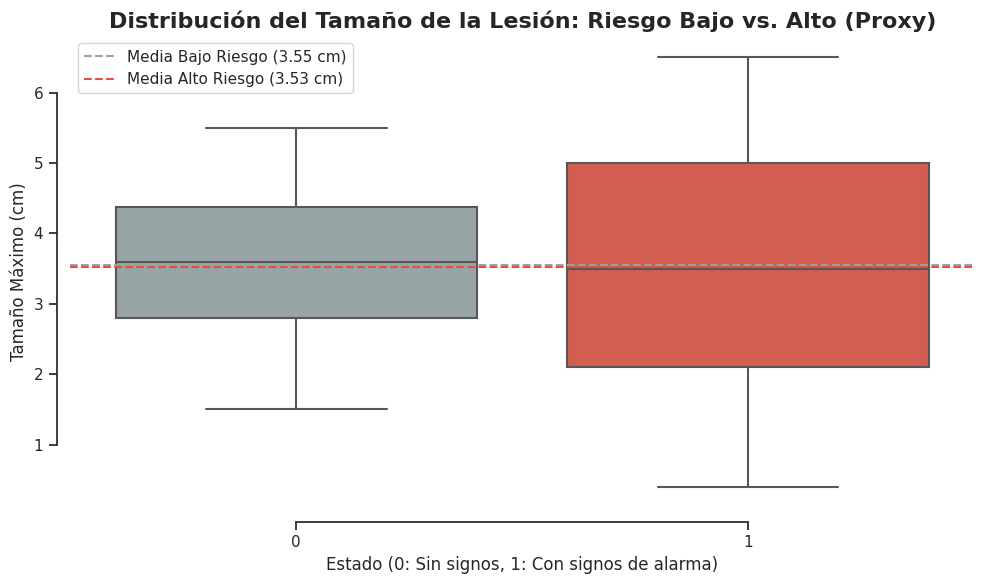

In [ ]:
plt.figure(figsize=(10, 6))

    # Gráfico de Caja: Tamaño vs Target
sns.boxplot(
x='diagnostico',
y='Tamaño máximo (cm)',
data=df_trabajo,
palette=['#95a5a6', '#e74c3c'], # Gris para bajo riesgo, Rojo para alto
linewidth=1.5
)

# Añadir líneas de media para comparar
media_bajo = df_trabajo[df_trabajo['diagnostico'] == 0] ['Tamaño máximo (cm)'].mean()
media_alto = df_trabajo[df_trabajo['diagnostico'] == 1] ['Tamaño máximo (cm)'].mean()

plt.axhline(y=media_bajo, color='#95a5a6', linestyle='--', label=f'Media Bajo Riesgo ({media_bajo:.2f} cm)')
plt.axhline(y=media_alto, color='#e74c3c', linestyle='--', label=f'Media Alto Riesgo ({media_alto:.2f} cm)')

plt.title('Distribución del Tamaño de la Lesión: Riesgo Bajo vs. Alto (Proxy)', fontsize=16, fontweight='bold')
plt.xlabel('Estado (0: Sin signos, 1: Con signos de alarma)', fontsize=12)
plt.ylabel('Tamaño Máximo (cm)', fontsize=12)
plt.legend()
sns.despine(offset=10, trim=True)
plt.tight_layout()
plt.show()

/tmp/ipykernel_22439/2796063274.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


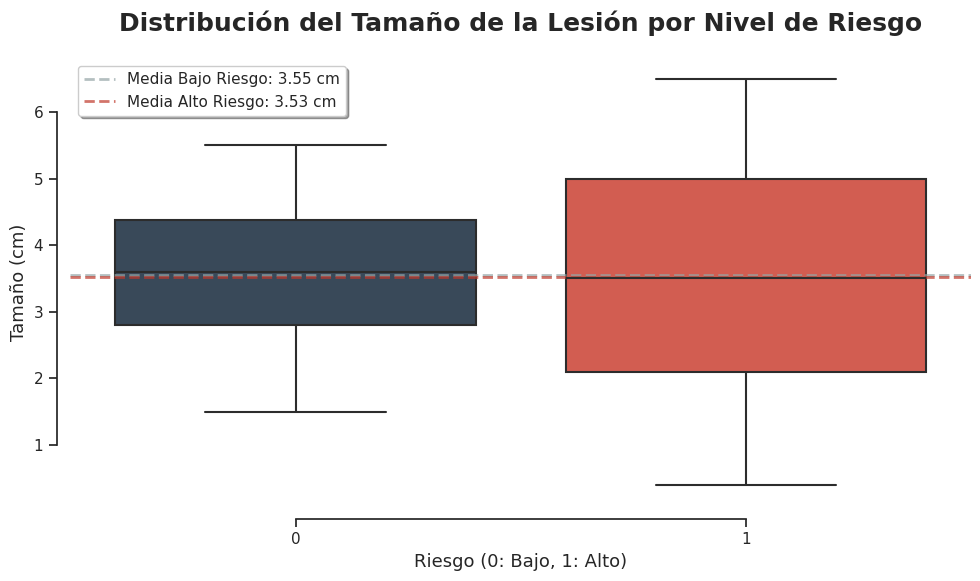

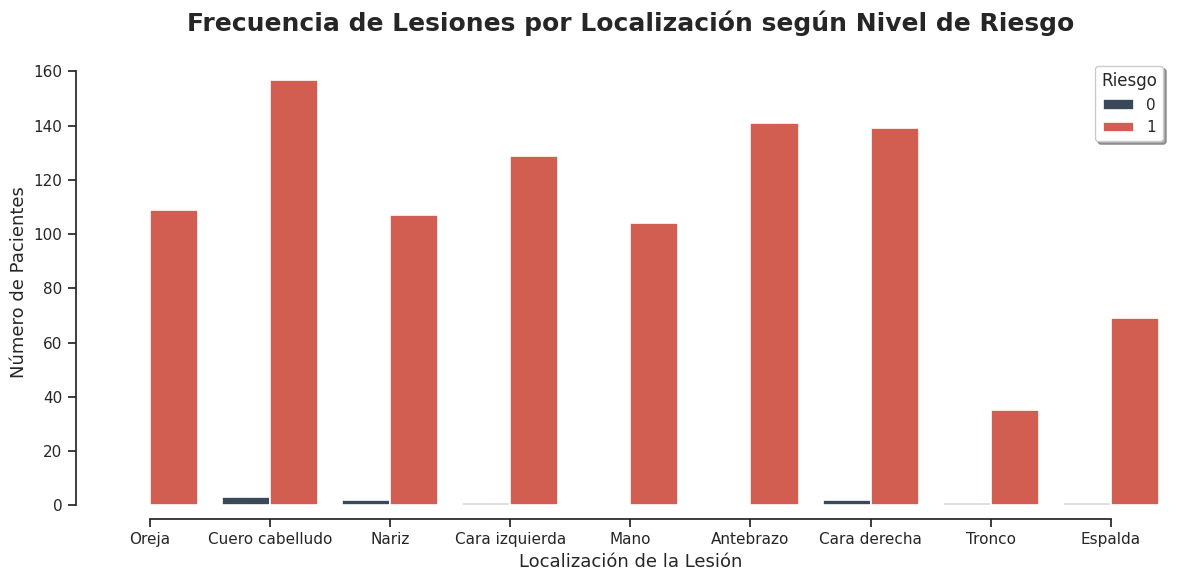

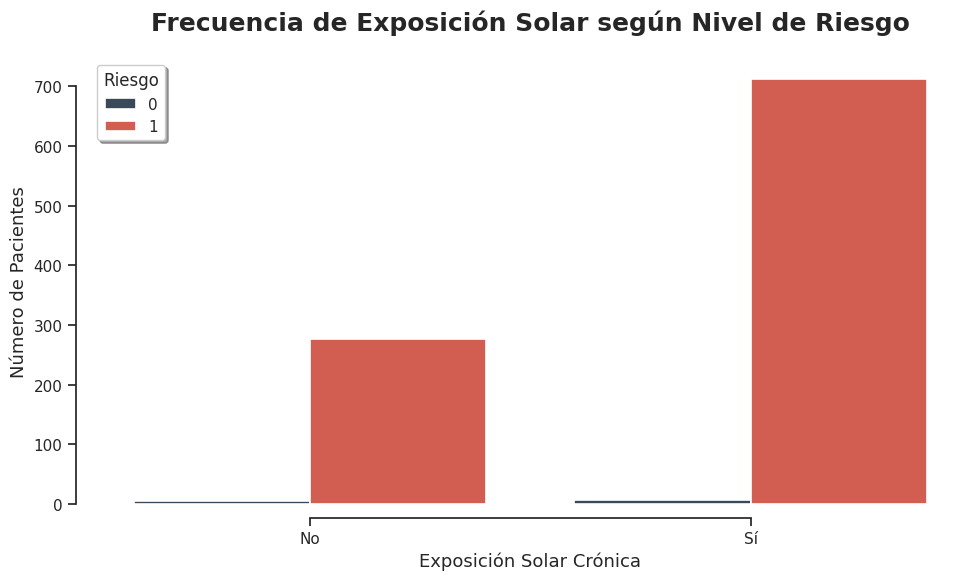

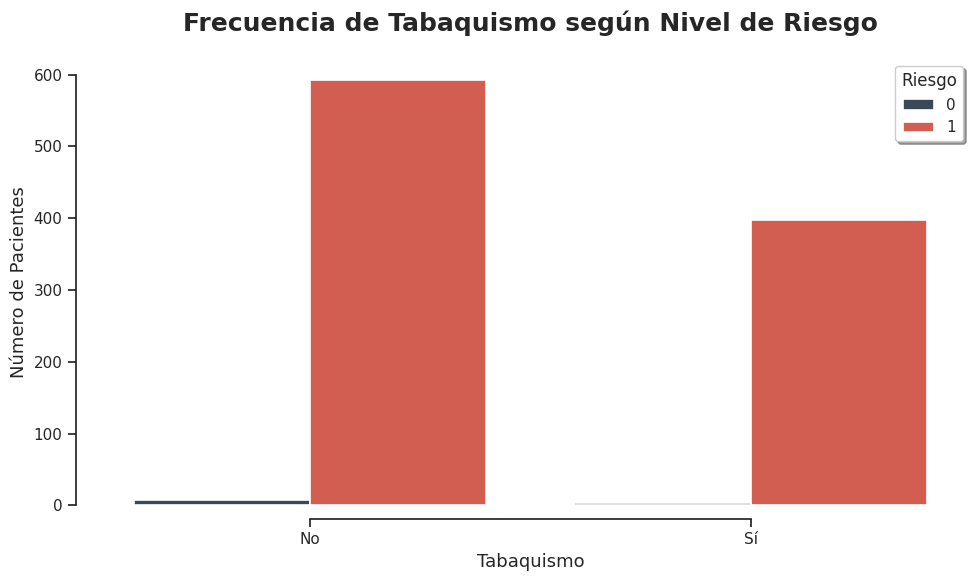

/tmp/ipykernel_22439/2796063274.py:114: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


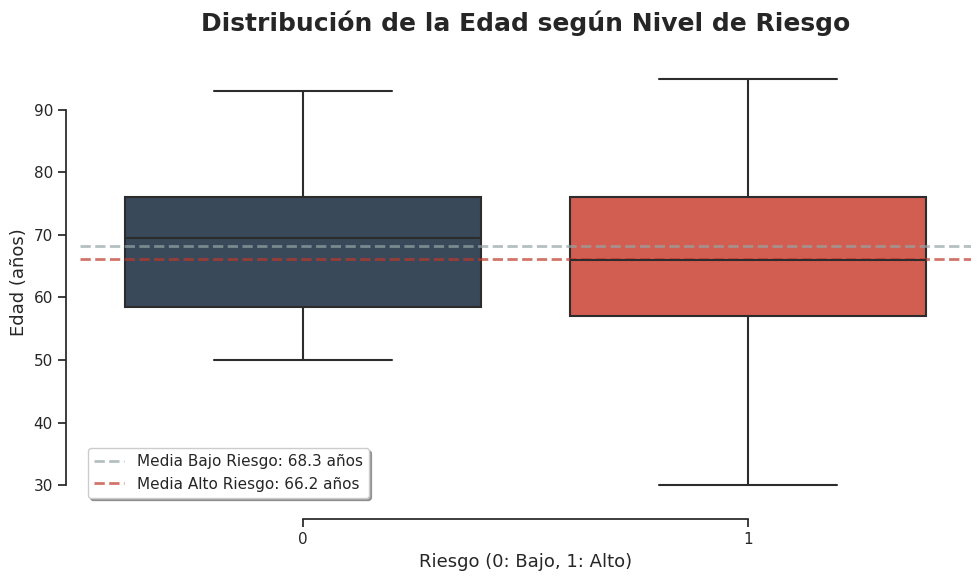

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Configuración global
sns.set_theme(style="ticks")
plt.rcParams['font.size'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

# 1. Verificar que 'diagnostico' existe (ya debería estar creado en tu celda anterior)
if 'diagnostico' not in df_trabajo.columns:
    # Si no existe, lo recreamos rápidamente con los nombres correctos
    signos = ['Ulceración o sangrado espontáneo', 'Bordes elevados/irregulares', 'Endurecimiento', 'Cambio reciente de tamaño/color', 'Costra persistente']
    validas = [c for c in signos if c in df_trabajo.columns]
    if validas:
        for col in validas:
            if df_trabajo[col].dtype == 'object':
                df_trabajo[col] = df_trabajo[col].map({'Sí': 1, 'Si': 1, 'Presente': 1, 'No': 0, 'Ausente': 0}).fillna(0).astype(int)
            else:
                df_trabajo[col] = df_trabajo[col].astype(int)
        df_trabajo['diagnostico'] = (df_trabajo[validas].sum(axis=1) > 0).astype(int)
    else:
        raise ValueError("No se encontraron columnas de síntomas para crear el diagnostico.")

# ==========================================
# 1. TAMAÑO MÁXIMO vs DIAGNOSTICO
# ==========================================
plt.figure(figsize=(10, 6))
sns.boxplot(
    x='diagnostico',
    y='Tamaño máximo (cm)',
    data=df_trabajo,
    palette=['#34495e', '#e74c3c'],
    linewidth=1.5,
    flierprops={'marker': 'o', 'markersize': 4, 'markerfacecolor': '#e74c3c', 'markeredgecolor': 'white'}
)
plt.title('Distribución del Tamaño de la Lesión por Nivel de Riesgo', fontsize=18, pad=20)
plt.xlabel('Riesgo (0: Bajo, 1: Alto)', fontsize=13)
plt.ylabel('Tamaño (cm)', fontsize=13)
media_0 = df_trabajo[df_trabajo['diagnostico'] == 0] ['Tamaño máximo (cm)'].mean()
media_1 = df_trabajo[df_trabajo['diagnostico'] == 1] ['Tamaño máximo (cm)'].mean()
plt.axhline(y=media_0, color='#95a5a6', linestyle='--', linewidth=2, alpha=0.7, label=f'Media Bajo Riesgo: {media_0:.2f} cm')
plt.axhline(y=media_1, color='#c0392b', linestyle='--', linewidth=2, alpha=0.7, label=f'Media Alto Riesgo: {media_1:.2f} cm')
plt.legend(frameon=True, fancybox=True, shadow=True, fontsize=11)
sns.despine(offset=10, trim=True)
plt.tight_layout()
plt.show()

# ==========================================
# 2. LOCALIZACIÓN vs DIAGNOSTICO
# ==========================================
plt.figure(figsize=(12, 6))
sns.countplot(
    data=df_trabajo,
    x='Localización de la lesión',
    hue='diagnostico',
    palette=['#34495e', '#e74c3c'],
    edgecolor='white',
    linewidth=1.2
)
plt.title('Frecuencia de Lesiones por Localización según Nivel de Riesgo', fontsize=18, pad=20)
plt.xlabel('Localización de la Lesión', fontsize=13)
plt.ylabel('Número de Pacientes', fontsize=13)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Riesgo', title_fontsize=12, fontsize=11, frameon=True, fancybox=True, shadow=True)
sns.despine(offset=10, trim=True)
plt.tight_layout()
plt.show()

# ==========================================
# 3. EXPOSICIÓN SOLAR vs DIAGNOSTICO
# ==========================================
plt.figure(figsize=(10, 6))
sns.countplot(
    data=df_trabajo,
    x='Exposición solar crónica',
    hue='diagnostico',
    palette=['#34495e', '#e74c3c'],
    edgecolor='white',
    linewidth=1.2
)
plt.title('Frecuencia de Exposición Solar según Nivel de Riesgo', fontsize=18, pad=20)
plt.xlabel('Exposición Solar Crónica', fontsize=13)
plt.ylabel('Número de Pacientes', fontsize=13)
plt.legend(title='Riesgo', title_fontsize=12, fontsize=11, frameon=True, fancybox=True, shadow=True)
sns.despine(offset=10, trim=True)
plt.tight_layout()
plt.show()

# ==========================================
# 4. TABAQUISMO vs DIAGNOSTICO
# ==========================================
plt.figure(figsize=(10, 6))
sns.countplot(
    data=df_trabajo,
    x='Tabaquismo',
    hue='diagnostico',
    palette=['#34495e', '#e74c3c'],
    edgecolor='white',
    linewidth=1.2
)
plt.title('Frecuencia de Tabaquismo según Nivel de Riesgo', fontsize=18, pad=20)
plt.xlabel('Tabaquismo', fontsize=13)
plt.ylabel('Número de Pacientes', fontsize=13)
plt.legend(title='Riesgo', title_fontsize=12, fontsize=11, frameon=True, fancybox=True, shadow=True)
sns.despine(offset=10, trim=True)
plt.tight_layout()
plt.show()

# ==========================================
# 5. EDAD vs DIAGNOSTICO
# ==========================================
plt.figure(figsize=(10, 6))
sns.boxplot(
    x='diagnostico',
    y='Edad (años)',
    data=df_trabajo,
    palette=['#34495e', '#e74c3c'],
    linewidth=1.5,
    flierprops={'marker': 'o', 'markersize': 4, 'markerfacecolor': '#e74c3c', 'markeredgecolor': 'white'}
)
plt.title('Distribución de la Edad según Nivel de Riesgo', fontsize=18, pad=20)
plt.xlabel('Riesgo (0: Bajo, 1: Alto)', fontsize=13)
plt.ylabel('Edad (años)', fontsize=13)
media_edad_0 = df_trabajo[df_trabajo['diagnostico'] == 0] ['Edad (años)'].mean()
media_edad_1 = df_trabajo[df_trabajo['diagnostico'] == 1] ['Edad (años)'].mean()
plt.axhline(y=media_edad_0, color='#95a5a6', linestyle='--', linewidth=2, alpha=0.7, label=f'Media Bajo Riesgo: {media_edad_0:.1f} años')
plt.axhline(y=media_edad_1, color='#c0392b', linestyle='--', linewidth=2, alpha=0.7, label=f'Media Alto Riesgo: {media_edad_1:.1f} años')
plt.legend(frameon=True, fancybox=True, shadow=True, fontsize=11)
sns.despine(offset=10, trim=True)
plt.tight_layout()
plt.show()